In [308]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [148]:
df = pd.read_csv('Customer Flight Activity.csv')
df1 = pd.read_csv('Customer Loyalty History.csv') 

In [237]:
def eda(df):
    print("========== RESUMEN GENERAL ==========")
    print(f"Filas x Columnas (shape): {df.shape}")
    print("\nColumnas:")
    print(df.columns.tolist()) 

    print("\nDtypes:")
    print(df.dtypes)

    print("\n============= NULOS ==============")
    if df.isnull().sum().sum() == 0:
        print("No hay valores nulos.")
    else:
        nulos = df.isnull().sum()
        porcentaje = df.isnull().sum() / df.shape[0] * 100
        tabla_nulos = pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": porcentaje})

        print(tabla_nulos)

    print("\n========== DESCRIBE NUMÉRICO ==========")
    print(df.describe().T)

    print("\n========== DESCRIBE CATEGÓRICO (object/category/str) ==========")
    if df.select_dtypes(include=["object", "category", "str"]).columns.tolist(): 
        print(df.describe(include=["object", "category", "str"]).T) 
    else: 
         print("No hay columnas categóricas.")
    
    print("\n========== DUPLICADOS ==========")
    print(f"Hay {df.duplicated().sum()} filas duplicadas.")

    print("\n========== HEAD ==========")
    display(df.head())

    print("\n========== TAIL ==========")
    display(df.tail())

    print("\n========== SAMPLE ==========")
    display(df.sample())

   
    


In [239]:
#Primero vamos a echar un vistazo general a los datos de df.
eda(df) 

========== RESUMEN GENERAL ==========
Filas x Columnas (shape): (405624, 10)

Columnas:
['Loyalty Number', 'Year', 'Month', 'Flights Booked', 'Flights with Companions', 'Total Flights', 'Distance', 'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed']

Dtypes:
Loyalty Number                   int64
Year                             int64
Month                            int64
Flights Booked                   int64
Flights with Companions          int64
Total Flights                    int64
Distance                         int64
Points Accumulated             float64
Points Redeemed                  int64
Dollar Cost Points Redeemed      int64
dtype: object

============= NULOS ==============
No hay valores nulos.

========== DESCRIBE NUMÉRICO ==========
                                count           mean            std       min  \
Loyalty Number               405624.0  550037.873084  258935.286969  100018.0   
Year                         405624.0    2017.500000    

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0
3,100214,2017,1,0,0,0,0,0.0,0,0
4,100272,2017,1,0,0,0,0,0.0,0,0



========== TAIL ==========


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
405619,999902,2018,12,0,0,0,0,0.0,0,0
405620,999911,2018,12,0,0,0,0,0.0,0,0
405621,999940,2018,12,3,0,3,1233,123.0,0,0
405622,999982,2018,12,0,0,0,0,0.0,0,0
405623,999986,2018,12,0,0,0,0,0.0,0,0



========== SAMPLE ==========


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
292584,381717,2018,6,0,0,0,0,0.0,0,0


In [146]:
#Veamos ahora los datos de df1.
eda(df1)

========== RESUMEN GENERAL ==========
Filas x Columnas (shape): (16737, 16)

Columnas:
['Loyalty Number', 'Country', 'Province', 'City', 'Postal Code', 'Gender', 'Education', 'Salary', 'Marital Status', 'Loyalty Card', 'CLV', 'Enrollment Type', 'Enrollment Year', 'Enrollment Month', 'Cancellation Year', 'Cancellation Month']

Dtypes:
Loyalty Number          int64
Country                   str
Province                  str
City                      str
Postal Code               str
Gender                    str
Education                 str
Salary                float64
Marital Status            str
Loyalty Card              str
CLV                   float64
Enrollment Type           str
Enrollment Year         int64
Enrollment Month        int64
Cancellation Year     float64
Cancellation Month    float64
dtype: object

============= NULOS ==============
                    Nulos  Porcentaje (%)
Loyalty Number          0        0.000000
Country                 0        0.000000
Province

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN



========== TAIL ==========


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,NaN,NaN
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN
16736,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049.0,Married,Star,83325.38,Standard,2015,12,2016.0,8.0



========== SAMPLE ==========


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
9644,776547,Canada,British Columbia,Victoria,V10 6T5,Female,High School or Below,69587.0,Married,Nova,25107.1,Standard,2015,1,NaN,NaN


In [ ]:
#Vamos a unir ambos dataframes para tener toda la información en uno solo.
df_aerolinea = pd.merge(df, df1, on="Loyalty Number", how="left")
df_aerolinea.sort_values(by="Loyalty Number")
eda(df_aerolinea)

In [254]:
#Hay filas duplicadas, así que empezamos por eliminarlas.
df_aerolinea = df_aerolinea.drop_duplicates()
df_aerolinea.duplicated().sum()

np.int64(0)

In [280]:
# La columna Loyalty Number es un ID de cliente, así que debería ser categórica, no numérica. La convertimos.
df_aerolinea['Loyalty Number'] = df_aerolinea['Loyalty Number'].astype(str)

In [ ]:
# Las columnas Month, Enrollment Month y Cancellation Month son numéricas, pero en realidad son meses, así que le vamos a poner los nombres para convertirlas en categóricas. 

meses ={1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
        7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}
for columna in df_aerolinea.columns:
    if 'Month' in columna:
        df_aerolinea[columna] = df_aerolinea[columna].map(meses)

# A las columnas Year, Enrollment Year y Cancellation Year las también la convertimos a categoría, ya que son numéricas pero no haremos operaciones con ellas.

for columna in df_aerolinea.columns:
    if 'Year' in columna:
        df_aerolinea[columna] = df_aerolinea[columna].astype('str')  

#El valor de las columnas Points Accumulated, Salary y CLV son números muy grandes, así que no vamos a necesitar decimales.     

df_aerolinea['Points Accumulated'] = df_aerolinea['Points Accumulated'].astype('int')
df_aerolinea['Salary'] = df_aerolinea['Salary'].astype('Int64') #  La convertimos a Int64 ya que hay nulos. 
df_aerolinea['CLV'] = df_aerolinea['CLV'].astype('int')

print(df_aerolinea.dtypes)
df_aerolinea.head(1)

In [256]:
# Mirando la descripción general de los datos, vemos que el valor mínimo de la columna Salary es un número negativo. Son los ingresos anuales estimados de los clientes, no debería haber valores negativos.
# Revisamos los valores únicos para ver si hay más.

print(sorted(df_aerolinea["Salary"].dropna().unique()))


# Comprobamos que sí los hay, pero de valores absolutos muy similares a los positivos, lo cual nos lleva a pensar que es un error. Lo arreglamos.
df_aerolinea['Salary'] = df_aerolinea['Salary'].abs()



[np.int64(-58486), np.int64(-57297), np.int64(-49830), np.int64(-49001), np.int64(-47310), np.int64(-46683), np.int64(-46470), np.int64(-46303), np.int64(-45962), np.int64(-43234), np.int64(-39503), np.int64(-34079), np.int64(-31911), np.int64(-26322), np.int64(-19332), np.int64(-19325), np.int64(-17534), np.int64(-12497), np.int64(-10605), np.int64(-9081), np.int64(15609), np.int64(16628), np.int64(16743), np.int64(16853), np.int64(17166), np.int64(17682), np.int64(18664), np.int64(18715), np.int64(19203), np.int64(19464), np.int64(20173), np.int64(20320), np.int64(20755), np.int64(20805), np.int64(21022), np.int64(21249), np.int64(21616), np.int64(21623), np.int64(21853), np.int64(21997), np.int64(22313), np.int64(22425), np.int64(22850), np.int64(23018), np.int64(23136), np.int64(23160), np.int64(23265), np.int64(24287), np.int64(24688), np.int64(25257), np.int64(25604), np.int64(25636), np.int64(25862), np.int64(26880), np.int64(26922), np.int64(26962), np.int64(27569), np.int64(27

In [333]:
#Ahora gestionemos los nulos. Primero vamos a ver cuántos nulos hay en cada columna y qué porcentaje representan, para decidir cómo gestionarlos.

nulos = df_aerolinea.isnull().sum()
porcentaje = df_aerolinea.isnull().sum() / df_aerolinea.shape[0] * 100
tabla_nulos = pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": porcentaje})
tabla_nulos.sort_values(by='Porcentaje (%)', ascending=False)

,Nulos,Porcentaje (%)
Loyalty Number,0,0.0
Postal Code,0,0.0
Cancellation Year,0,0.0
Enrollment Month,0,0.0
Enrollment Year,0,0.0
Enrollment Type,0,0.0
CLV,0,0.0
Loyalty Card,0,0.0
Marital Status,0,0.0
Salary,0,0.0


In [294]:
# En primer lugar vemos que Cancellation Month y Cancellation year tienen exactamente el mismo porcentaje de nulos, lo que probablemente se deba a que es la fecha de cancelación de la membresía. 
# Lo cual nos lleva a pensar que los nulos significan que siguen subcritos, así que los vamos a imputar con una nueva categoría llamada "Still Member".
df_aerolinea['Cancellation Month'] = df_aerolinea['Cancellation Month'].fillna('Still Member')
df_aerolinea['Cancellation Year'] = df_aerolinea['Cancellation Year'].fillna('Still Member')

In [295]:
# Ahora hay que decidir qué hacer con los nulos de la columna Salary. Primero vamos a ver si hay alguna relación entre los nulos de Salary y otras columnas, para ver si podemos imputarlos con algún valor relacionado.

pd.crosstab(df_aerolinea['Salary'].isna(), df_aerolinea['Education']).reset_index()

Education,Salary,Bachelor,College,Doctor,High School or Below,Master
0,False,252567,0,17731,18915,12287
1,True,0,102260,0,0,0


In [271]:
#todos los nulos son de clientes suyo nivel de estudios es college. Miramos cuantos salarios de la categoría college tenemos.
mask = df_aerolinea['Education'] == 'College'
df_aerolinea['Salary'][mask].count()
#no hay ningún dato de salario para clientes con nivel de estudios college, así que no podemos imputar con la mediana de esa categoría.



np.int64(0)

In [307]:
# Miramos si hay relación entre los salarios, el nivel de estudios y el género. 
df_aerolinea.groupby(['Education', 'Gender'])['Salary'].mean().round(2).sort_values(ascending=False).reset_index()

,Education,Gender,Salary
0,Doctor,Male,181276.44
1,Doctor,Female,175594.68
2,Master,Male,105036.54
3,Master,Female,102549.31
4,Bachelor,Female,72757.82
5,Bachelor,Male,72437.76
6,High School or Below,Female,61237.59
7,High School or Below,Male,61050.45
8,College,Female,<NA>
9,College,Male,<NA>


In [ ]:
# Visto que sí hay relación, vamos a imputar los nulos por la mediana de salarios entre bachelor y high school or below teniendo en cuenta el género.

mask_educacion = df_aerolinea['Education'].isin(['Bachelor', 'High School or Below'])

mediana_por_genero = df_aerolinea[mask_educacion].groupby('Gender')['Salary'].median()

# Ahora por fin, imputamos los nulos de Salary
def imputar_nulos_salary(row):
    if pd.isna(row['Salary']): #si encuentras un nulo, .
        return mediana_por_genero[row['Gender']] # devuelveme la mediana según el género(me da la fila según el género).
    return row['Salary'] #sino, devuelveme el salario original

df_aerolinea['Salary'] = df_aerolinea.apply(imputar_nulos_salary, axis=1)  # aquí ejecuta para cada fila y lo sobreescribe.


In [340]:
# para finalizar cambiamos el tipo de dato de Int64 a int.
df_aerolinea['Salary'] = df_aerolinea['Salary'].astype(int)

In [346]:
#veamos las columnas numéricas 
desc = df_aerolinea.describe().T 
#añadimos media y moda
desc['median'] = df_aerolinea.median(numeric_only=True)
desc['mode']   = df_aerolinea.mode(numeric_only=True).iloc[0]  # iloc[0] porque mode puede devolver varios valores

desc

,count,mean,std,min,25%,50%,75%,max,median,mode
Flights Booked,403760.0,4.134050,5.230064,0.0,0.0,1.0,8.0,21.0,1.0,0
Flights with Companions,403760.0,1.036569,2.080472,0.0,0.0,0.0,1.0,11.0,0.0,0
Total Flights,403760.0,5.170619,6.526858,0.0,0.0,1.0,10.0,32.0,1.0,0
Distance,403760.0,1214.460979,1434.098521,0.0,0.0,525.0,2342.0,6293.0,525.0,0
Points Accumulated,403760.0,124.237924,146.675448,0.0,0.0,53.0,240.0,676.0,53.0,0
Points Redeemed,403760.0,30.838587,125.758002,0.0,0.0,0.0,0.0,876.0,0.0,0
Dollar Cost Points Redeemed,403760.0,2.495973,10.172033,0.0,0.0,0.0,0.0,71.0,0.0,0
Salary,403760.0,77219.261804,30235.168504,9081.0,63901.0,71009.0,82940.0,407228.0,71009.0,70741
CLV,403760.0,7990.365269,6863.315849,1898.0,3981.0,5776.0,8937.0,83325.0,5776.0,6005


Hallazgos más relevantes:

**Salary**: la media (77k) y la mediana (71k) están relativamente próximas, pero el máximo (407k) está muy por encima del Q3 (83k), lo que indica una cola derecha pronunciada con outliers altos claros.

**CLV**: mismo patrón — mediana 5.776, pero máximo 83.325. La mayoría de clientes tienen un valor moderado, pero hay una minoría con CLV extremadamente alto.

**Points Redeemed y Dollar Cost Points Redeemed**: mediana y Q3 en 0, pero máximos de 876 y 71 respectivamente. La gran mayoría de clientes no canjea puntos, lo que hace que los que sí lo hacen aparezcan como outliers estadísticos.

**Distance**: mediana 525 vs máximo 6.293, con Q1 en 0, lo que sugiere que muchos clientes no volaron ese mes y unos pocos hicieron distancias muy largas.


En general, estas variables presentan distribuciones asimétricas hacia la derecha típicas de datos de comportamiento de clientes, donde la mayoría tiene valores bajos pero una minoría genera valores extremos que no son errores, sino clientes de alto valor o uso intensivo.

<Axes: >

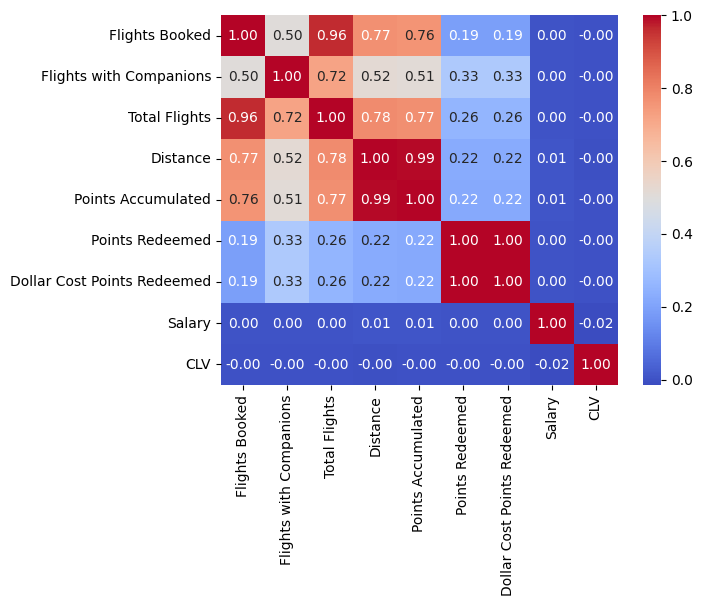

In [347]:
# Hacemos un mapa de calor para ver las correlaciones
sns.heatmap(df_aerolinea.corr(numeric_only=True), annot=True, fmt='.2f', cmap="coolwarm")

**Correlaciones fuertes:**

**_Points Redeemed vs Dollar Cost Points Redeemed (1)_**: es una correlación perfecta. Seguramente son la misma variable expresada en unidades distintas (lo que valen los puntos en dólares).

**_Distance vs Points Accumulated (0.99)_**: prácticamente perfecta. Habitualmente los puntos se acumulan en función de los kilómetros volados.

**_Flights Booked vs Total Flights (0.96)_**: bastante lógico, ya que Total Flights es la suma de Flights Booked y Flights with Companions.

**Correlaciones moderadas:**

**_Flights Booked/Total Flights vs Distance/Points Accumulated (0.76-0.78)_**: los clientes que vuelam más, acumulan más puntos y recorren más distancia. Suena bastante lógico.

**_Flights with Companions vs Flights Booked/ Total Flights (0.50-0.72)_**: correlación moderada, ya que volar con acompañantes depende mas bien de otros factores que no son la cantidad de veces que vuela el cliente, pero sí que si vuela con acompañantes, aumenta la cantidad de vuelos reservados y con ello, los vuelos totales. 

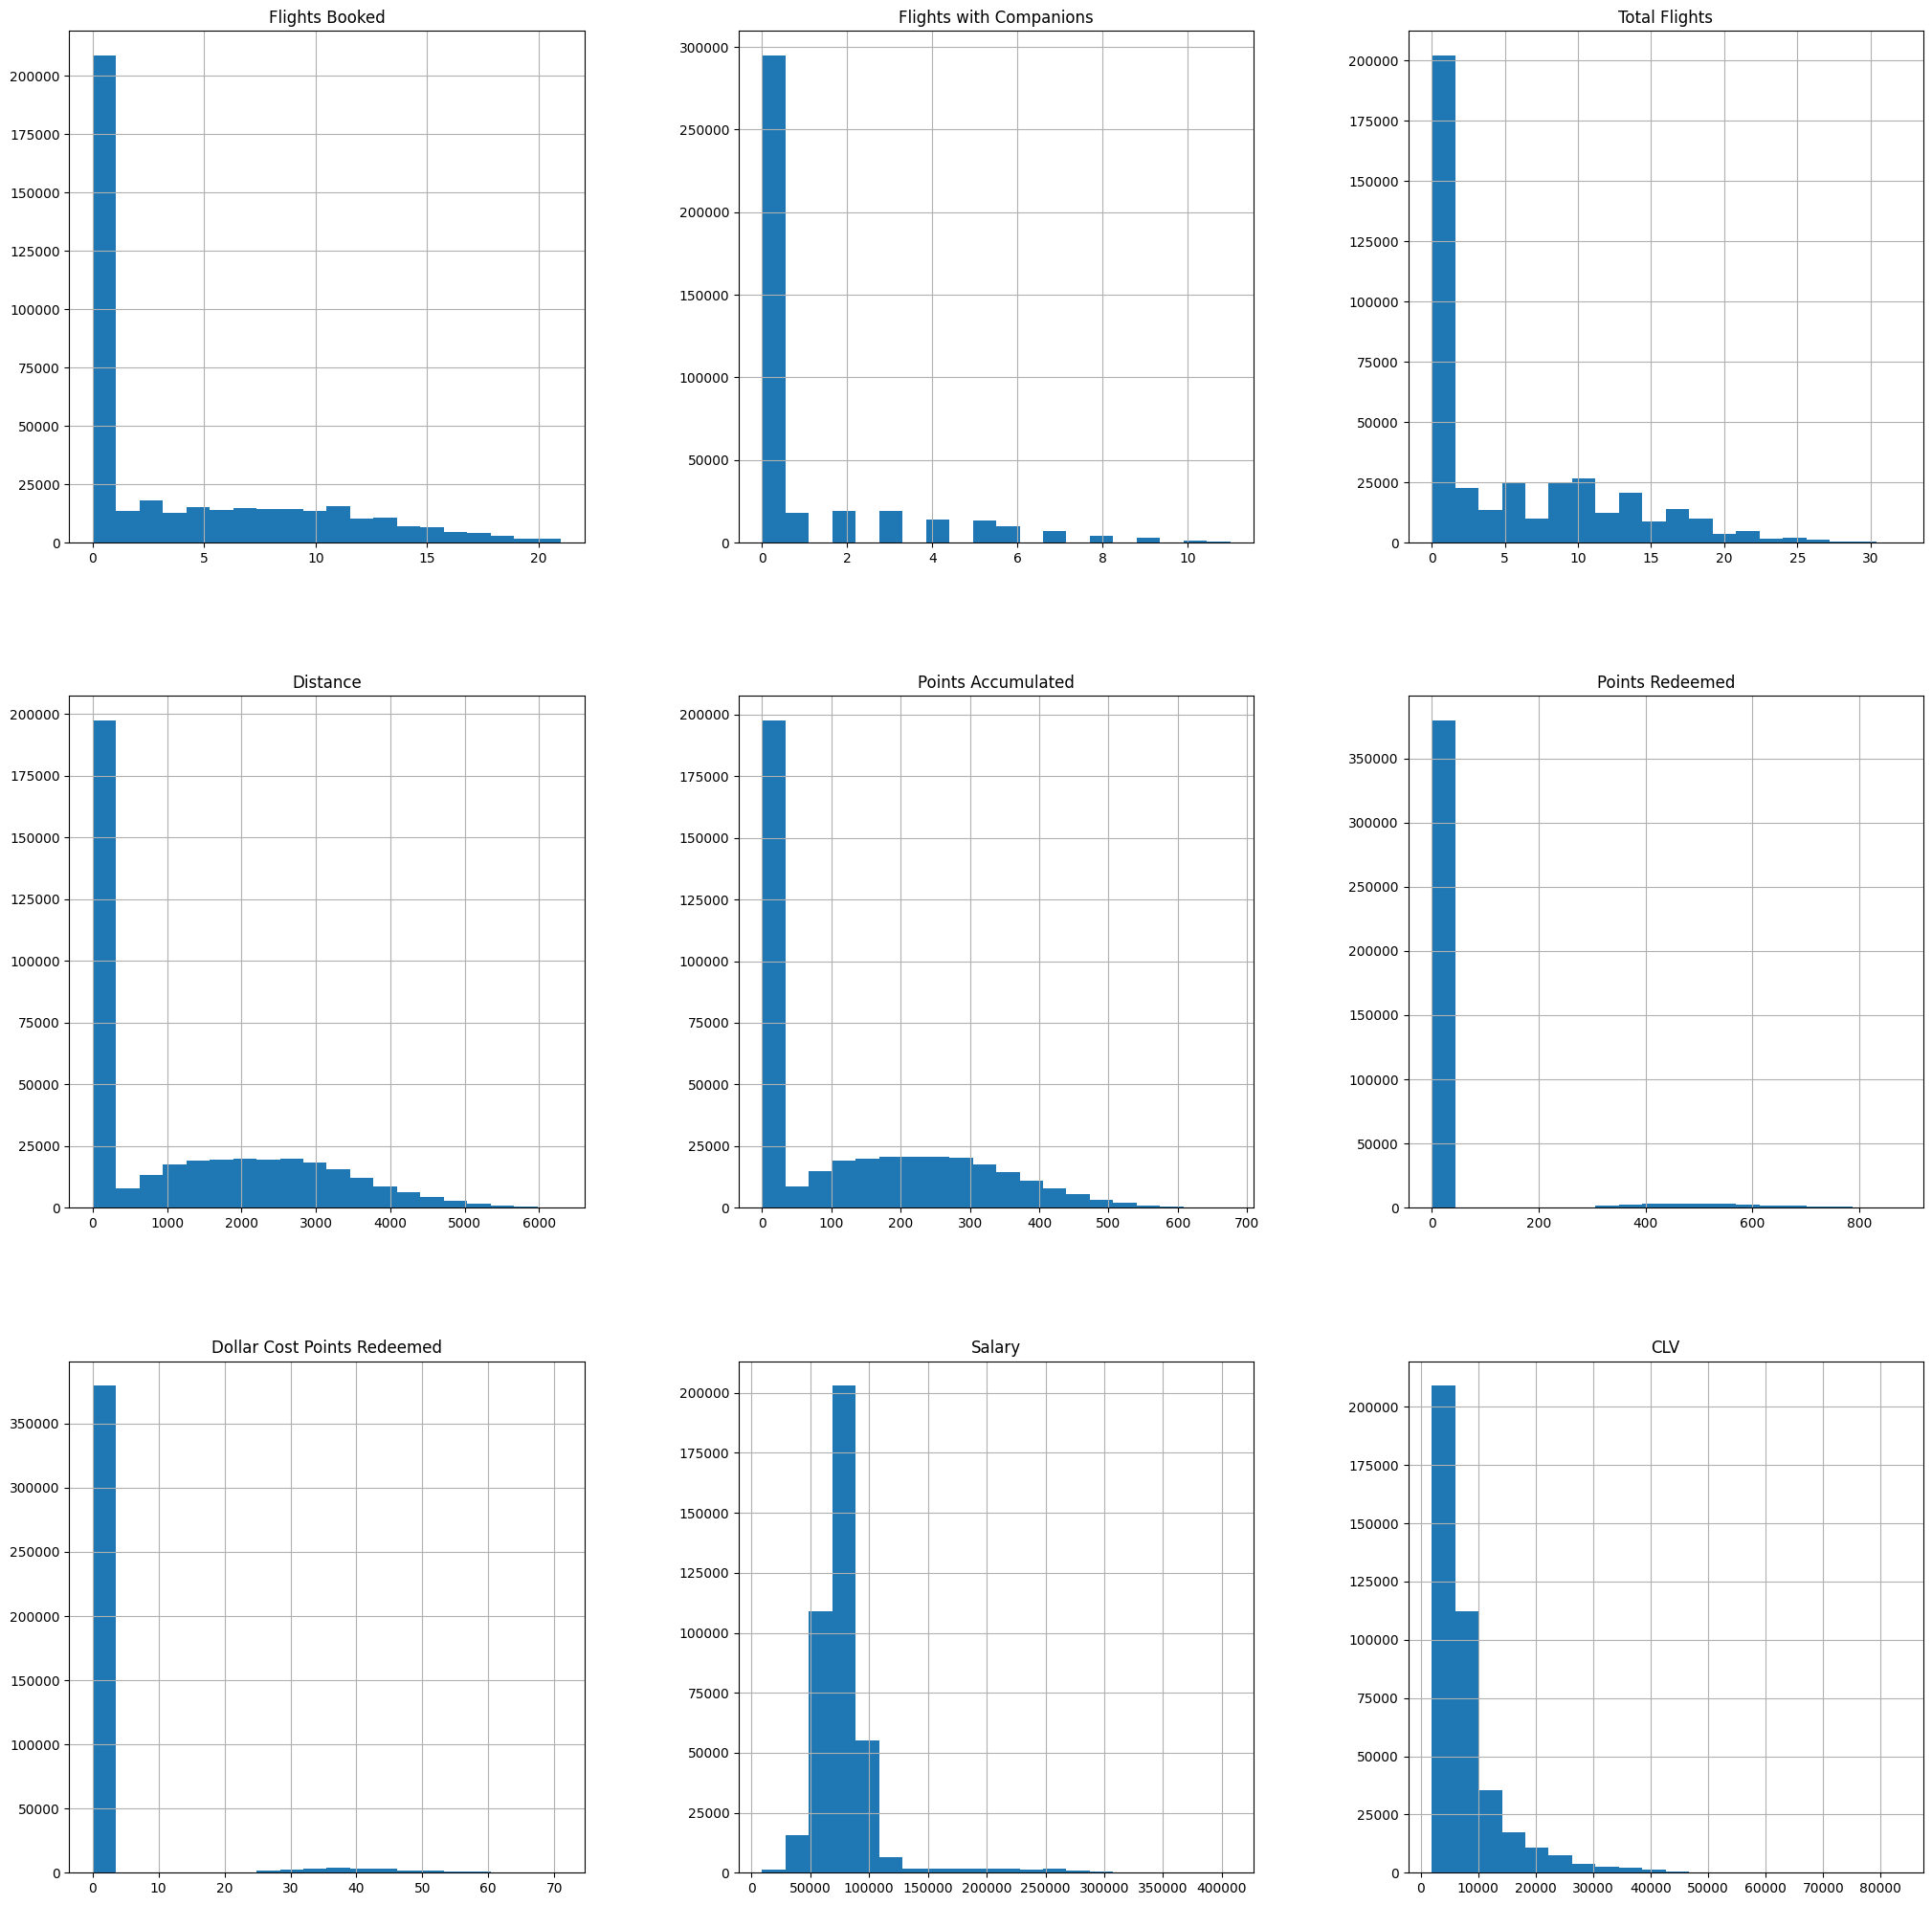

In [ ]:
df_aerolinea.plot(bins=20, figsize=(25,25))
plt.show()